# PyTorch Workflow Fundamentals

In [2]:
import torch
import matplotlib.pyplot as plt
from torch import nn

## 1. Data (preparing and loading)

In [7]:
# membuat parameter
weight = 0.7
bias = 0.3

# membuat  data
start = 0
end  = 1
step = 0.02

X = torch.arange(start=start,end=end,step=step).unsqueeze(dim=1)
y = weight * X + bias

X [: 10 ],  y [: 10 ]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [8]:
# Buat pembagian data latih/uji 

train_split = int(0.8 * len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [10]:
# membuat Visualisasi
def plot_predictions(train_data,train_labels,test_data,test_labels,predictions = None):
    """Plots training data, test data and compares predictions."""
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_labels,c="b", s=4, label="Training data")
    plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
    plt.legend(prop={'size':15})

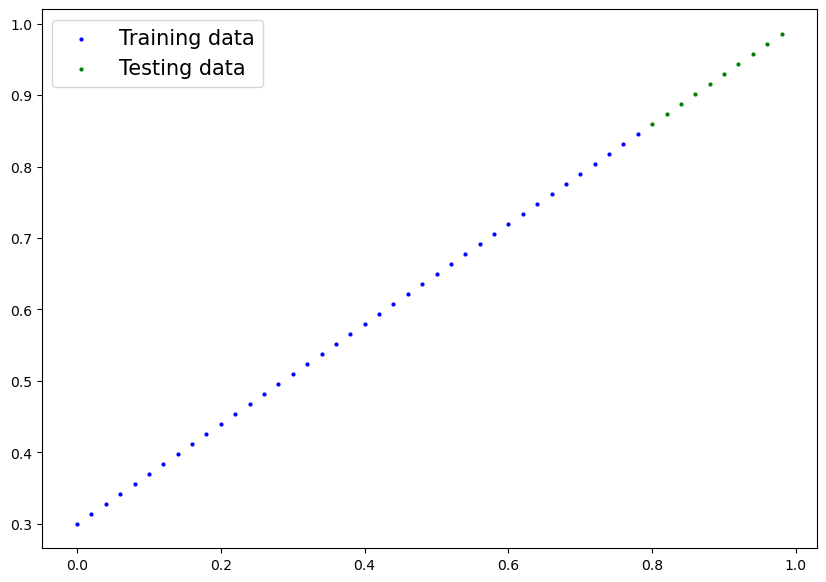

In [11]:
plot_predictions(train_data=X_train,train_labels=y_train,test_data=X_test,test_labels=y_test)

## 2. Build model

In [13]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1,dtype=torch.float),requires_grad=True)

    def forward(self,X:torch.Tensor)-> torch.Tensor:
        return self.weights * X + self.bias

In [14]:
### 2.1 Checking the contents of a PyTorch model

In [ ]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()

list(model_0.parameters()),model_0.state_dict()

([Parameter containing:
  tensor([0.3367], requires_grad=True),
  Parameter containing:
  tensor([0.1288], requires_grad=True)],
 OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))]))